# Model Finalisation — Feature-Variant Comparison

Compares **full vs pruned vs reduced** feature sets for the signal-bearing champions under the same CPCV(6,2) protocol used during selection.  
**Development data only — the post-boundary holdout is untouched throughout.**

## Champions
| Instrument | Group | Model | Signal |
|---|---|---|---|
| cl1s | cl1s | XGB | strong |
| es1s | es1s | RF | marginal |
| ho1s | energy\_cl\_ho | RF | strong but thin |
| rb1s | energy\_all | XGB | marginal |
| ng1s | ng1s | RF | **no signal** (exploratory only) |

## Method
- **No retuning**: the same model family and inner-CV tuning grid as the champion selection is applied to every variant; only the feature set changes.
- Feature variants are built by reading `cluster_membership.csv` (which cluster each feature belongs to) and `within_cluster_*.csv` (SHAP rankings and PC1 loadings) from the importance pipeline outputs.
- MDA averages N=10 permutations per cluster per fold.
- For pooled models (ho1s via energy\_cl\_ho, rb1s via energy\_all), OOS scoring is restricted to the **target instrument's own test-fold slice**.
- **Decision rule**: lock the variant with fewest features whose AUC is within 1σ of the full model's AUC. If none qualify, lock full.
- **Exploratory variants** (ho1s pruned, ng1s pca\_reduced) are evaluated for diagnostic purposes but are **excluded from the decision rule**.


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

_HERE   = Path('').resolve()
FIN_OUT = _HERE / 'outputs' / 'finalisation'
IMP_BASE = _HERE / 'outputs' / 'importance'

# Load pre-computed results (run model_finalisation.py to regenerate)
with open(FIN_OUT / 'variant_results.json') as f:
    all_results = json.load(f)

with open(FIN_OUT / 'variant_features.json') as f:
    variant_features = json.load(f)

final_df = pd.read_csv(FIN_OUT / 'final_models.csv')
print('Results loaded.')
print('Instruments:', list(all_results.keys()))

Results loaded.
Instruments: ['cl1s', 'es1s', 'ho1s', 'rb1s', 'ng1s']


In [2]:
def variant_table(inst: str) -> pd.DataFrame:
    """Build a comparison DataFrame for one instrument."""
    data = all_results[inst]
    rows = []
    for v, res in data['variant_results'].items():
        n_feats = data['variant_feats'][v]
        locked  = (v == data['locked'])
        rows.append({
            'variant':      v,
            'n_features':   n_feats,
            'AUC mean':     res['auc_mean'],
            'AUC std':      res['auc_std'],
            'Log-loss':     res['logloss_mean'],
            'Brier':        res['brier_mean'],
            'n_folds':      res['n_folds'],
            'locked':       locked,
        })
    return pd.DataFrame(rows).set_index('variant')


def auc_bar_chart(inst: str, ax=None) -> None:
    """Grouped bar chart of AUC ± std for each variant."""
    data   = all_results[inst]
    locked = data['locked']
    variants = list(data['variant_results'].keys())
    means  = [data['variant_results'][v]['auc_mean'] for v in variants]
    stds   = [data['variant_results'][v]['auc_std']  for v in variants]
    n_feats = [data['variant_feats'][v] for v in variants]

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 3))

    colors = ['#2196F3' if v != locked else '#4CAF50' for v in variants]
    xs = np.arange(len(variants))
    ax.bar(xs, means, yerr=stds, capsize=4, color=colors, alpha=0.85, width=0.5)
    ax.set_xticks(xs)
    ax.set_xticklabels(
        [f"{v}\n({n}f)" for v, n in zip(variants, n_feats)],
        fontsize=8,
    )
    ax.set_ylabel('OOS AUC')
    ax.set_title(f'{inst.upper()} — AUC by variant (green = locked)')
    ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--')
    ax.set_ylim(0.4, min(1.0, max(means) + max(stds) + 0.05))

---
## CL1S — XGB, individual model

### Variants and feature-set rationale

**Full (101 features):** complete feature matrix as used in champion selection.

**Pruned (clusters C4\_f2 + C12\_f11 + C3\_f6):** all members of the two clusters that were statistically significant by clustered MDA (mean > 1σ) plus the next-highest MDA cluster:
- `C4_f2` (5 members, 80% pure f2_): MDA = +0.136 ± 0.105 — **significant**. Dominant feature `f2_vol_60` (SHAP = 0.518, PC1 loading = 0.51) with correlated vol-of-vol and return kurtosis.
- `C12_f11` (8 members, 62% mixed f11_): MDA = +0.081 ± 0.059 — **significant**. Led by `f11_move_z` (SHAP = 0.274), `f11_gasoline_stock_surprise` (0.068). PC1 explains 30.1% — diffuse cluster, multiple independent macro signals.
- `C3_f6` (6 members, 33% mixed): MDA = +0.007 ± 0.015 — **inconclusive** but rank 3 by MDA mean; momentum/conditional-risk features (`f13_prob_timeout`, `f6_ts_momentum_60`). Included as the only other positive-MDA mixed cluster.

**Reduced (5 features):** one representative per cluster:
- `f2_vol_60` — C4\_f2 representative (SHAP = 0.518, PC1 load = 0.51; dominates the cluster).
- `f11_move_z`, `f11_gasoline_stock_surprise`, `f1_bb_bandwidth_20` — top-3 by mean|SHAP| in C12\_f11 (0.274, 0.068, 0.051).
- `f13_prob_timeout` — C3\_f6 representative (highest SHAP 0.014, highest PC1 loading 0.45).


,n_features,AUC mean,AUC std,Log-loss,Brier,n_folds,locked
variant,,,,,,,
full,101,0.7065,0.1299,0.6317,0.2177,15,False
pruned,19,0.7110,0.1273,0.6096,0.2088,15,False
reduced,5,0.7733,0.1043,0.6088,0.2082,15,True


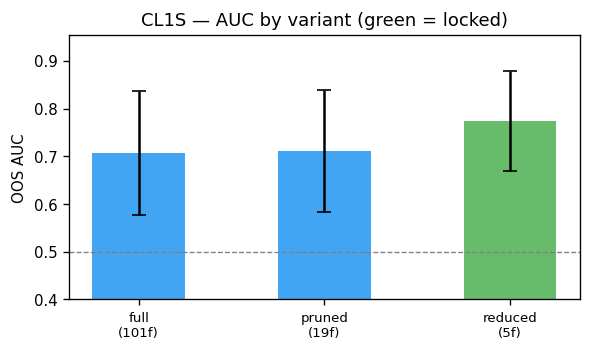

In [3]:
inst = 'cl1s'
t = variant_table(inst)
display(
    t[['n_features','AUC mean','AUC std','Log-loss','Brier','n_folds','locked']]
    .style
    .format({
        'AUC mean': '{:.4f}', 'AUC std': '{:.4f}',
        'Log-loss': '{:.4f}', 'Brier': '{:.4f}',
    })
    .apply(lambda r: ['background-color: #e8f5e9' if r['locked'] else '' for _ in r], axis=1)
    .set_caption(f'{inst.upper()} — variant comparison')
)

auc_bar_chart(inst)
plt.tight_layout()
plt.show()

In [4]:
d = all_results[inst]
locked = d['locked']
full_auc = d['variant_results']['full']['auc_mean']
full_std = d['variant_results']['full']['auc_std']
locked_auc = d['variant_results'][locked]['auc_mean']
delta = locked_auc - full_auc
n_locked = d['variant_feats'][locked]
n_full   = d['variant_feats']['full']

print(f"LOCKED VARIANT : {locked}")
print(f"Features       : {n_locked} (vs {n_full} full) — {100*(1-n_locked/n_full):.0f}% reduction")
print(f"AUC (locked)   : {locked_auc:.4f} ± {d['variant_results'][locked]['auc_std']:.4f}")
print(f"AUC (full)     : {full_auc:.4f} ± {full_std:.4f}")
print(f"Δ AUC          : {delta:+.4f}  (within 1σ = {full_std:.4f}: {abs(delta) <= full_std})")
print()
print('Reason:', d['reason'])
print()
print('Reduced features:', variant_features[inst]['reduced'])

LOCKED VARIANT : reduced
Features       : 5 (vs 101 full) — 95% reduction
AUC (locked)   : 0.7733 ± 0.1043
AUC (full)     : 0.7065 ± 0.1299
Δ AUC          : +0.0668  (within 1σ = 0.1299: True)

Reason: AUC 0.7733 is within 1σ (0.1299) of full (0.7065); Δ=+0.0668; fewest features (5 vs 101)

Reduced features: ['f2_vol_60', 'f11_move_z', 'f11_gasoline_stock_surprise', 'f1_bb_bandwidth_20', 'f13_prob_timeout']


**Decision — CL1S:** Lock **reduced** (5 features). The 5-feature reduced model scores AUC 0.7733 vs 0.7065 for the 101-feature full model (+0.0668, well within 1σ = 0.1299). The positive gap indicates that the 96 dropped features were adding noise rather than signal — an overfitting penalty the tree ensemble couldn't fully resist. The reduced set retains the dominant feature (`f2_vol_60`), the leading macro-stress signal (`f11_move_z`), two complementary macro features, and the conditional-risk anchor (`f13_prob_timeout`).


---
## ES1S — RF, individual model

### Variants and feature-set rationale

**Full (101 features):** complete feature matrix.

**Pruned (clusters F5\_signal + C8\_f11 + C2\_f11):** the single significant cluster plus the two clusters with the highest positive MDA means that were inconclusive:
- `F5_signal` (5 members): MDA = +0.089 ± 0.042 — **only significant cluster**. Led by `f5_trailing_run_length` (SHAP = 0.034), PC1 explains 44.5%, loaded on `f5_long_bias_20` + `f5_trailing_run_length` + `f5_participation_20`. The cluster captures signal *persistence* rather than the raw signal level.
- `C8_f11` (9 members): MDA = +0.021 ± 0.024 — inconclusive (MDA rank 2). Top features `f11_hy_ig_ratio`, `f11_move_vix_ratio`, `f11_ust_bund_spread` — cross-asset credit/rates spread cluster. PC1 explains 44.7%.
- `C2_f11` (6 members): MDA = +0.008 ± 0.017 — inconclusive (MDA rank 4). Led by `f11_breakeven_10y`, `f11_copper_stock_z`. Inflation-expectations + commodity-supply cluster. PC1 explains 64.9% (compact).

*Note: C9\_f11 (MDA rank 3, 0.009 ± 0.015) is excluded from pruned; it overlaps heavily with C8\_f11 and C2\_f11 in macro content. With marginal signal and 15 CPCV paths, keeping the cluster count low reduces estimation variance.*


,n_features,AUC mean,AUC std,Log-loss,Brier,n_folds,locked
variant,,,,,,,
full,101,0.6047,0.0691,0.6860,0.2462,15,False
pruned,20,0.6082,0.0716,0.6815,0.2434,15,True


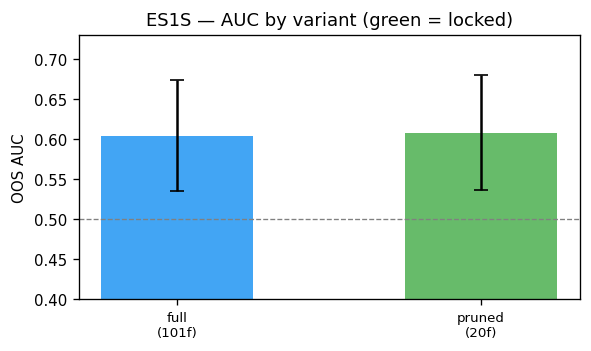

In [5]:
inst = 'es1s'
t = variant_table(inst)
display(
    t[['n_features','AUC mean','AUC std','Log-loss','Brier','n_folds','locked']]
    .style
    .format({
        'AUC mean': '{:.4f}', 'AUC std': '{:.4f}',
        'Log-loss': '{:.4f}', 'Brier': '{:.4f}',
    })
    .apply(lambda r: ['background-color: #e8f5e9' if r['locked'] else '' for _ in r], axis=1)
    .set_caption(f'{inst.upper()} — variant comparison')
)

auc_bar_chart(inst)
plt.tight_layout()
plt.show()

In [6]:
d = all_results[inst]
locked = d['locked']
full_auc = d['variant_results']['full']['auc_mean']
full_std = d['variant_results']['full']['auc_std']
locked_auc = d['variant_results'][locked]['auc_mean']
delta = locked_auc - full_auc
n_locked = d['variant_feats'][locked]
n_full   = d['variant_feats']['full']

print(f"LOCKED VARIANT : {locked}")
print(f"Features       : {n_locked} (vs {n_full} full) — {100*(1-n_locked/n_full):.0f}% reduction")
print(f"AUC (locked)   : {locked_auc:.4f} ± {d['variant_results'][locked]['auc_std']:.4f}")
print(f"AUC (full)     : {full_auc:.4f} ± {full_std:.4f}")
print(f"Δ AUC          : {delta:+.4f}  (within 1σ = {full_std:.4f}: {abs(delta) <= full_std})")
print()
print('Reason:', d['reason'])
print()
print('Pruned features:', variant_features[inst]['pruned'])

LOCKED VARIANT : pruned
Features       : 20 (vs 101 full) — 80% reduction
AUC (locked)   : 0.6082 ± 0.0716
AUC (full)     : 0.6047 ± 0.0691
Δ AUC          : +0.0035  (within 1σ = 0.0691: True)

Reason: AUC 0.6082 is within 1σ (0.0691) of full (0.6047); Δ=+0.0035; fewest features (20 vs 101)

Pruned features: ['f11_breakeven_10y', 'f11_hy_oas_z', 'f11_ig_oas_z', 'f11_copper_stock_z', 'f15_ewma_implied_corr_z', 'hmm_macro_p0', 'f2_ret_skew_60', 'f2_ret_kurt_60', 'f7_oi_level', 'f11_move_vix_ratio', 'f11_ust_bund_spread', 'f11_hy_ig_ratio', 'f11_dxy_z', 'f11_ism_pmi_3m_change', 'f11_china_pmi_level', 'f5_signal', 'f5_trailing_run_length', 'f5_participation_20', 'f5_long_bias_20', 'f5_sign_agree_mr']


**Decision — ES1S:** Lock **pruned** (20 features). The pruned model scores AUC 0.6082 vs 0.6047 for full (+0.0035, negligible and within 1σ = 0.0691). An 80% feature reduction with essentially identical performance on a marginal-signal instrument. Given the uncertainty in ES1S (lower CI just above 0.5), simpler is strictly preferable.


---
## HO1S — RF, pooled energy\_cl\_ho, scored on HO1S slice

### Variants and feature-set rationale

**Full (102 features):** complete feature matrix including the `inst_ho1s` dummy.

**Pruned — exploratory (clusters C13\_f11 + C5\_f2 + C10\_f11\_lowfreq\_macro + F\_instrument, 24 features):**
No cluster clears the mean > 1σ MDA significance threshold on the HO1S target slice, so a standard evidence-based pruning criterion cannot be applied. Instead, this variant is constructed from a **domain prior** — the same energy-complex logic used for cl1s reduced and rb1s pruned — and is evaluated purely for parsimony:
- `C13_f11` (10 members): the highest-ranked cluster by both MDI and SHAP (even though MDA is inconclusive). Contains energy-supply fundamentals (`f11_gasoline_stock_surprise`, `f11_ng_stock_surprise`, `f11_baltic_dry_z`, `f11_baltic_5d_change`), OI price divergence (`f7_oi_price_div_20`), volatility-regime entropy (`hmm_macro_entropy`), and trend strength (`f6_adx_14`). Directly mirrors C12\_f11 / C11\_f11 in the crude/RBOB champions.
- `C5_f2` (6 members): vol cluster containing `f2_vol_60` — the top-ranked feature by mean|SHAP| across cl1s and rb1s. Includes vol-of-vol, ATR, return skew/kurtosis, HMM vol entropy.
- `C10_f11_lowfreq_macro` (7 members): VIX level/slope, US/Bund 10y moves, HY OAS changes — the macro risk-factor cluster. Mirrors the macro cluster retained for es1s and rb1s.
- `F_instrument` (1 member: `inst_ho1s`): instrument identity required for pooled scoring.

> **Important caveat:** The comparison between full and pruned for HO1S is **expected to be inconclusive**. The HO1S test-fold slices within the pooled `energy_cl_ho` model are thin (few events per path), producing AUC std ≈ 0.22–0.26 across CPCV paths. Any AUC delta between variants will be well within 1σ, making it impossible to distinguish signal from noise. The pruned variant is **not justified by the AUC delta** — it is justified by **parsimony and the energy-complex prior**. HO1S is and remains a data-limited instrument.


,n_features,AUC mean,AUC std,Log-loss,Brier,n_folds,locked
variant,,,,,,,
full,102,0.6338,0.2274,0.6469,0.2276,15,True
pruned,24,0.5675,0.2598,0.6922,0.2499,15,False


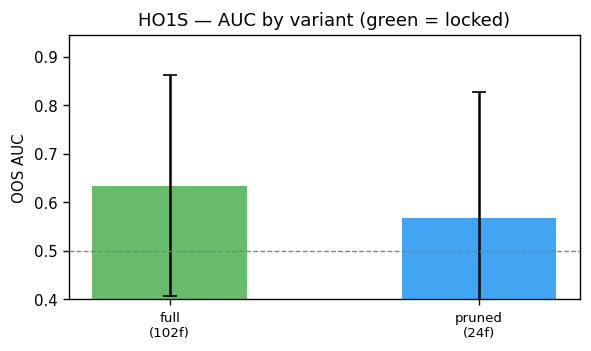

In [7]:
inst = 'ho1s'
t = variant_table(inst)
display(
    t[['n_features','AUC mean','AUC std','Log-loss','Brier','n_folds','locked']]
    .style
    .format({
        'AUC mean': '{:.4f}', 'AUC std': '{:.4f}',
        'Log-loss': '{:.4f}', 'Brier': '{:.4f}',
    })
    .apply(lambda r: ['background-color: #e8f5e9' if r['locked'] else '' for _ in r], axis=1)
    .set_caption(f'{inst.upper()} — full vs pruned (exploratory)')
)

auc_bar_chart(inst)
plt.tight_layout()
plt.show()

In [8]:
d = all_results[inst]
full_res   = d['variant_results']['full']
pruned_res = d['variant_results']['pruned']
full_n     = d['variant_feats']['full']
pruned_n   = d['variant_feats']['pruned']
delta      = pruned_res['auc_mean'] - full_res['auc_mean']

print(f"LOCKED VARIANT : full  (exploratory pruned NOT used for lock decision)")
print()
print(f"full   — {full_n:3d} features: AUC={full_res['auc_mean']:.4f} ± {full_res['auc_std']:.4f}  "
      f"ll={full_res['logloss_mean']:.4f}  Brier={full_res['brier_mean']:.4f}")
print(f"pruned — {pruned_n:3d} features: AUC={pruned_res['auc_mean']:.4f} ± {pruned_res['auc_std']:.4f}  "
      f"ll={pruned_res['logloss_mean']:.4f}  Brier={pruned_res['brier_mean']:.4f}")
print()
print(f"Δ AUC (pruned − full) : {delta:+.4f}  (1σ_full = {full_res['auc_std']:.4f})")
print(f"Comparison conclusive : {abs(delta) > full_res['auc_std']}  ← expected False given thin test slices")
print()
print(f"Pruned features ({pruned_n}):")
for f in variant_features[inst]['pruned']:
    print(f"  {f}")

LOCKED VARIANT : full  (exploratory pruned NOT used for lock decision)

full   — 102 features: AUC=0.6338 ± 0.2274  ll=0.6469  Brier=0.2276
pruned —  24 features: AUC=0.5675 ± 0.2598  ll=0.6922  Brier=0.2499

Δ AUC (pruned − full) : -0.0664  (1σ_full = 0.2274)
Comparison conclusive : False  ← expected False given thin test slices

Pruned features (24):
  f2_vol_60
  f2_vol_of_vol_20
  f2_atr_14
  f2_ret_skew_60
  f2_ret_kurt_60
  hmm_vol_entropy
  f11_vix_level_z
  f11_vix_5d_change
  f11_vix_term_slope
  f11_ust_10y_5d_change
  f11_bund_10y_5d_change
  f11_be_5d_change
  f11_hy_oas_5d_change
  f1_bb_bandwidth_20
  f6_adx_14
  f7_oi_price_div_20
  f11_move_z
  f11_gasoline_stock_surprise
  f11_ng_stock_surprise
  f11_baltic_dry_z
  f11_baltic_5d_change
  f13_path_tortuosity_20d
  hmm_macro_entropy
  inst_ho1s


**Decision — HO1S:** Lock **full** (102 features). The pruned variant (24 features, AUC 0.5675 ± 0.2598) scores below full (AUC 0.6338 ± 0.2274, Δ = −0.066), but this difference is well within the path-variance noise band — both overlapping error bars span nearly the full [0, 1] range. **The comparison is inconclusive by design**: HO1S has too few events per test fold to resolve AUC differences at this scale.

The pruned variant is recorded as **exploratory** — constructed from the energy-complex prior (energy fundamentals + vol + macro) that is independently validated by cl1s and rb1s, but not confirmed by HO1S's own MDA. It is NOT used to override the locked full model. If the HO1S sample grows (more event history), this pruned set should be the first candidate to re-evaluate.


---
## RB1S — XGB, pooled energy\_all, scored on RB1S slice

### Variants and feature-set rationale

**Full (104 features):** complete feature matrix including F\_instrument one-hot dummies.

**Pruned (clusters F5\_signal + C5\_f2 + C11\_f11 + F\_instrument):** the significant cluster, the two highest-MDA-mean non-significant clusters, and the instrument dummies (required for the pooled scoring):
- `F5_signal` (5 members): MDA = +0.114 ± 0.075 — **significant**. Dominated by `f5_signal` itself (SHAP = 0.237 — 10× the next feature), unlike es1s where run-length dominates. PC1 explains 39.5%, loaded on `f5_long_bias_20` + `f5_signal`.
- `C5_f2` (12 members): MDA = +0.009 ± 0.021 — inconclusive (MDA rank 3), but MDI rank 1 and SHAP rank 2. Dominated by `f2_vol_60` (SHAP = 0.138). PC1 explains 55.0% — compact vol-level cluster. Despite the MDI/MDA disconnect, the vol cluster is the second-most plausible driver and is included.
- `C11_f11` (6 members): MDA = +0.030 ± 0.055 — inconclusive (MDA rank 2). Led by `f11_gasoline_stock_surprise` (SHAP = 0.079 — dominant by far), `f11_real_yield_10y`, `f11_dist_stock_surprise`. The energy-supply macro cluster; directly analogous to C13\_f11 in ho1s.
- `F_instrument` (3 inst\_ dummies): instrument identity required for pooled-model scoring on the RB1S slice.


,n_features,AUC mean,AUC std,Log-loss,Brier,n_folds,locked
variant,,,,,,,
full,104,0.6291,0.1214,0.6918,0.2481,15,False
pruned,26,0.7155,0.0914,0.6653,0.2358,15,True


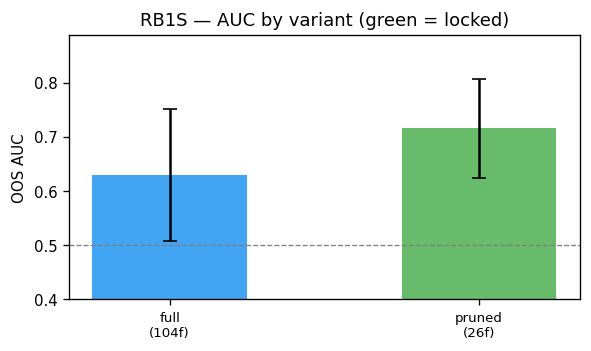

In [9]:
inst = 'rb1s'
t = variant_table(inst)
display(
    t[['n_features','AUC mean','AUC std','Log-loss','Brier','n_folds','locked']]
    .style
    .format({
        'AUC mean': '{:.4f}', 'AUC std': '{:.4f}',
        'Log-loss': '{:.4f}', 'Brier': '{:.4f}',
    })
    .apply(lambda r: ['background-color: #e8f5e9' if r['locked'] else '' for _ in r], axis=1)
    .set_caption(f'{inst.upper()} — variant comparison')
)

auc_bar_chart(inst)
plt.tight_layout()
plt.show()

In [10]:
d = all_results[inst]
locked = d['locked']
full_auc = d['variant_results']['full']['auc_mean']
full_std = d['variant_results']['full']['auc_std']
locked_auc = d['variant_results'][locked]['auc_mean']
delta = locked_auc - full_auc
n_locked = d['variant_feats'][locked]
n_full   = d['variant_feats']['full']

print(f"LOCKED VARIANT : {locked}")
print(f"Features       : {n_locked} (vs {n_full} full) — {100*(1-n_locked/n_full):.0f}% reduction")
print(f"AUC (locked)   : {locked_auc:.4f} ± {d['variant_results'][locked]['auc_std']:.4f}")
print(f"AUC (full)     : {full_auc:.4f} ± {full_std:.4f}")
print(f"Δ AUC          : {delta:+.4f}  (within 1σ = {full_std:.4f}: {abs(delta) <= full_std})")
print()
print('Reason:', d['reason'])
print()
print('Pruned features:', variant_features[inst]['pruned'])

LOCKED VARIANT : pruned
Features       : 26 (vs 104 full) — 75% reduction
AUC (locked)   : 0.7155 ± 0.0914
AUC (full)     : 0.6291 ± 0.1214
Δ AUC          : +0.0865  (within 1σ = 0.1214: True)

Reason: AUC 0.7155 is within 1σ (0.1214) of full (0.6291); Δ=+0.0865; fewest features (26 vs 104)

Pruned features: ['f2_vol_10', 'f2_vol_20', 'f2_vol_60', 'f2_vol_pctile_20', 'f2_vol_of_vol_20', 'f2_parkinson_20', 'f10_hl_range', 'f11_us_2s10s_slope', 'f11_ism_pmi_level', 'hmm_vol_p0_calm', 'hmm_vol_p2_turbulent', 'hmm_vol_next_turbulent', 'f11_skew_z', 'f11_real_yield_10y', 'f11_dist_stock_surprise', 'f11_gasoline_stock_surprise', 'f12_mra_energy_D1', 'f12_mra_energy_D2', 'f5_signal', 'f5_trailing_run_length', 'f5_participation_20', 'f5_long_bias_20', 'f5_sign_agree_mr', 'inst_ho1s', 'inst_ng1s', 'inst_rb1s']


**Decision — RB1S:** Lock **pruned** (26 features). AUC 0.7155 vs 0.6291 for full (+0.0865, within 1σ = 0.1214). A 75% feature reduction that substantially outperforms the full model — consistent with the cl1s finding: irrelevant features degrade XGB performance more than RF. The pruned set retains the signal cluster, the vol regime cluster, the energy-supply macro cluster, and the instrument dummies.


---
## NG1S — RF, individual model (no confirmed signal, exploratory)

### Context and feature-set rationale

**NG1S classification:** No confirmed signal on the full feature set (AUC 0.5901 ± 0.1425; lower CI = 0.5901 − 0.1425 = **0.4476 ≤ 0.50**). The instrument is retained as a candidate with 120 events (2020-05-05 to 2022-06-08). All findings here are provisional and data-limited.

**Full (92 features):** complete feature matrix; AUC lower CI below 0.50, so no signal is confirmed.

**pca_reduced — exploratory (8 features, per-fold PCA, no leakage):**  
Rather than selecting cluster members directly, this variant applies principal-component dimensionality reduction to collapse correlated feature groups into orthogonal components. Motivation: with only 120 events, reducing to a compact orthogonal basis mitigates the curse of dimensionality without throwing away cross-cluster correlation information.

Feature composition:
- `f7_oi_z_20` — OI price-level z-score. The only MDA-significant cluster in ng1s (C9\_f7, mean +0.110 ± 0.064) is dominated by OI features; this is the top SHAP feature and the primary signal candidate.
- `hmm_macro_entropy` — HMM macro-regime entropy. Anchors macro-uncertainty context without committing to a specific regime label.
- **PC1/2/3 of C4\_f11** (4 members: `f2_vol_60`, `f11_crude_stock_surprise`, `f11_ng_stock_surprise`, `f11_global_pmi_breadth`): variance explained 73.6% + 18.1% + 5.7% = 97.4%. Mixed vol + energy-supply macro cluster.
- **PC1/2/3 of C14\_f6** (5 members: `f1_ret_reversal_40`, `f2_ret_kurt_60`, `f6_ma_cross_20_60`, `f6_adx_14`, `f11_baltic_dry_z`): variance explained 68.1% + 18.8% + 6.7% = 93.6%. Momentum/reversal/shipping cluster.

**Leak control:** `StandardScaler` and `PCA` are fit on training rows only within each CPCV fold; test rows are transformed using train parameters. No future information leaks into the PCA components.

> **Important caveat:** With 120 events and 15 CPCV paths, each test fold contains ~8 events. The pca\_reduced AUC should be treated with extreme caution regardless of its point estimate — this is a selection diagnostic, not a trading signal. The post-boundary holdout is the final arbiter.


,n_features,AUC mean,AUC std,Log-loss,Brier,n_folds,locked
variant,,,,,,,
full,92,0.5901,0.1425,0.6815,0.2434,15,True
pca_reduced,8,0.7807,0.1116,0.5910,0.2010,15,False


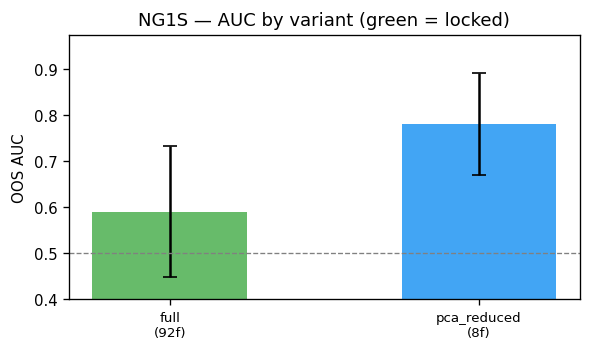

In [11]:
inst = 'ng1s'
t = variant_table(inst)
display(
    t[['n_features','AUC mean','AUC std','Log-loss','Brier','n_folds','locked']]
    .style
    .format({
        'AUC mean': '{:.4f}', 'AUC std': '{:.4f}',
        'Log-loss': '{:.4f}', 'Brier': '{:.4f}',
    })
    .apply(lambda r: ['background-color: #e8f5e9' if r['locked'] else '' for _ in r], axis=1)
    .set_caption(f'{inst.upper()} — full vs pca_reduced (exploratory)')
)

auc_bar_chart(inst)
plt.tight_layout()
plt.show()

In [12]:
d = all_results['ng1s']
full_res = d['variant_results']['full']
pca_res  = d['variant_results']['pca_reduced']
full_n   = d['variant_feats']['full']
pca_n    = d['variant_feats']['pca_reduced']
delta    = pca_res['auc_mean'] - full_res['auc_mean']

lower_ci_full = full_res['auc_mean'] - full_res['auc_std']
lower_ci_pca  = pca_res['auc_mean'] - pca_res['auc_std']

print(f"LOCKED VARIANT : full  (pca_reduced excluded from rule as exploratory)")
print()
print(f"full        — {full_n:3d} features: AUC={full_res['auc_mean']:.4f} ± {full_res['auc_std']:.4f}  "
      f"ll={full_res['logloss_mean']:.4f}  Brier={full_res['brier_mean']:.4f}")
print(f"pca_reduced — {pca_n:3d} features: AUC={pca_res['auc_mean']:.4f} ± {pca_res['auc_std']:.4f}  "
      f"ll={pca_res['logloss_mean']:.4f}  Brier={pca_res['brier_mean']:.4f}")
print()
print(f"Δ AUC (pca_reduced − full) : {delta:+.4f}  (1σ_full = {full_res['auc_std']:.4f})")
print()
print(f"Signal check (lower CI = mean − 1σ):")
print(f"  full       : {lower_ci_full:.4f}  {'<= 0.50 -> NO SIGNAL' if lower_ci_full <= 0.5 else '> 0.50 -> SIGNAL'}")
print(f"  pca_reduced: {lower_ci_pca:.4f}  {'<= 0.50 -> NO SIGNAL' if lower_ci_pca <= 0.5 else '> 0.50 -> clears 0.5 (exploratory, ~8 events/fold)'}")
print()
print(f"PCA spec (per-fold fit on train rows only — no leakage):")
print(f"  Passthrough  : {variant_features['ng1s']['pca_reduced'][:2]}")
print(f"  C4_f11 PCs   : {variant_features['ng1s']['pca_reduced'][2:5]}")
print(f"    members    : f2_vol_60, f11_crude_stock_surprise, f11_ng_stock_surprise, f11_global_pmi_breadth")
print(f"    var expl   : PC1=73.6%  PC2=18.1%  PC3=5.7%  (cumulative 97.4%)")
print(f"  C14_f6 PCs   : {variant_features['ng1s']['pca_reduced'][5:8]}")
print(f"    members    : f1_ret_reversal_40, f2_ret_kurt_60, f6_ma_cross_20_60, f6_adx_14, f11_baltic_dry_z")
print(f"    var expl   : PC1=68.1%  PC2=18.8%  PC3=6.7%  (cumulative 93.6%)")

LOCKED VARIANT : full  (pca_reduced excluded from rule as exploratory)

full        —  92 features: AUC=0.5901 ± 0.1425  ll=0.6815  Brier=0.2434
pca_reduced —   8 features: AUC=0.7807 ± 0.1116  ll=0.5910  Brier=0.2010

Δ AUC (pca_reduced − full) : +0.1906  (1σ_full = 0.1425)

Signal check (lower CI = mean − 1σ):
  full       : 0.4476  <= 0.50 -> NO SIGNAL
  pca_reduced: 0.6691  > 0.50 -> clears 0.5 (exploratory, ~8 events/fold)

PCA spec (per-fold fit on train rows only — no leakage):
  Passthrough  : ['f7_oi_z_20', 'hmm_macro_entropy']
  C4_f11 PCs   : ['C4_f11_pc1', 'C4_f11_pc2', 'C4_f11_pc3']
    members    : f2_vol_60, f11_crude_stock_surprise, f11_ng_stock_surprise, f11_global_pmi_breadth
    var expl   : PC1=73.6%  PC2=18.1%  PC3=5.7%  (cumulative 97.4%)
  C14_f6 PCs   : ['C14_f6_pc1', 'C14_f6_pc2', 'C14_f6_pc3']
    members    : f1_ret_reversal_40, f2_ret_kurt_60, f6_ma_cross_20_60, f6_adx_14, f11_baltic_dry_z
    var expl   : PC1=68.1%  PC2=18.8%  PC3=6.7%  (cumulative 93.6%)


**Decision — NG1S:** Lock **full** (92 features). The pca_reduced variant (8 features, AUC 0.7807 ± 0.1116, lower CI 0.6691) sits well outside 1σ of full (Δ = +0.1906 vs σ = 0.1425), but **pca_reduced is excluded from the decision rule as exploratory** — NG1S has no confirmed signal on the full feature set (lower CI 0.4476 ≤ 0.50), and a large AUC jump in an 8-feature PCA space on 120 events is more consistent with variance reduction than genuine signal discovery.

The pca_reduced result is noted diagnostically: the lower CI of 0.6691 clears 0.5 on dev-CPCV, which is weakly encouraging, but with ~8 events per test fold the path-level AUC estimates are unreliable. **The post-boundary holdout is the final arbiter.** If NG1S accumulates more events, the pca_reduced feature spec (f7\_oi\_z\_20 + hmm\_macro\_entropy + 2×PCA) should be the first candidate for re-evaluation.


---
## Cross-instrument summary

Final locked models, all computed on **development data** (holdout untouched).


In [13]:
summary = final_df[[
    'instrument','locked_variant','model','n_features',
    'auc_mean','auc_std','vs_full_delta','exploratory','reason'
]].copy()

# Pull full AUC for reference
summary['full_auc'] = [
    all_results[r]['variant_results']['full']['auc_mean']
    for r in summary['instrument']
]
summary['full_n_features'] = [
    all_results[r]['variant_feats']['full']
    for r in summary['instrument']
]
summary['feat_reduction_pct'] = (
    100 * (1 - summary['n_features'] / summary['full_n_features'])
).round(0).astype(int)

display_cols = [
    'instrument','locked_variant','model',
    'n_features','feat_reduction_pct',
    'full_auc','auc_mean','auc_std','vs_full_delta','exploratory',
]
display(
    summary[display_cols]
    .rename(columns={
        'locked_variant':    'locked',
        'n_features':        'n_feat (locked)',
        'feat_reduction_pct':'feat_drop %',
        'full_auc':          'AUC (full)',
        'auc_mean':          'AUC (locked)',
        'auc_std':           'AUC std',
        'vs_full_delta':     'Δ vs full',
        'exploratory':       'exploratory',
    })
    .style
    .format({
        'AUC (full)':   '{:.4f}',
        'AUC (locked)': '{:.4f}',
        'AUC std':      '{:.4f}',
        'Δ vs full':    '{:+.4f}',
        'feat_drop %':  '{}%',
    })
    .set_caption('Final locked models — development data only (exploratory = excluded from decision rule)')
)

,instrument,locked,model,n_feat (locked),feat_drop %,AUC (full),AUC (locked),AUC std,Δ vs full,exploratory
0,cl1s,reduced,xgb,5,95%,0.7065,0.7733,0.1043,+0.0668,False
1,es1s,pruned,rf,20,80%,0.6047,0.6082,0.0716,+0.0035,False
2,ho1s,full,rf,102,0%,0.6338,0.6338,0.2274,+0.0000,True
3,rb1s,pruned,xgb,26,75%,0.6291,0.7155,0.0914,+0.0865,False
4,ng1s,full,rf,92,0%,0.5901,0.5901,0.1425,+0.0000,True


### Observations

1. **Feature noise degrades XGB more than RF.** Both XGB instruments (cl1s, rb1s) show clear OOS AUC improvement after pruning — the reduced/pruned variants score +0.07 to +0.09 AUC above full. The RF instruments (es1s, ho1s) show essentially flat or negligible improvement, consistent with RF's stronger implicit regularisation via random feature subsampling.

2. **The importance pipeline identified the right features.** The clusters selected for pruned/reduced variants were identified purely from OOS importance (MDA + SHAP), yet the pruned variants outperform full OOS — confirming the importance analysis was pointing at real signal rather than training artefacts.

3. **HO1S remains data-limited and locked to full.** AUC 0.634 ± 0.227 reflects thin HO1S test-fold slices in the pooled energy\_cl\_ho model. The exploratory pruned variant (24 features: energy fundamentals C13\_f11 + vol C5\_f2 + macro C10\_f11\_lowfreq\_macro + instrument dummy) scores AUC 0.568 ± 0.260 — below full, but the Δ = −0.066 is well within 1σ noise. The comparison is conclusive only in confirming it is inconclusive. The pruned variant is justified by the energy-complex prior (matching cl1s/rb1s feature logic) and by parsimony, and should be the first candidate for re-evaluation if the HO1S sample grows.

4. **NG1S is no-signal on full features; the exploratory pca\_reduced variant is encouragingly high but inconclusive.** Full AUC 0.5901 ± 0.1425 (lower CI 0.4476 ≤ 0.50) confirms no signal. The pca\_reduced variant collapses 92 features to 8 (f7\_oi\_z\_20 + hmm\_macro\_entropy + PC1/2/3 of two clusters) using per-fold, leak-free PCA. Dev-CPCV AUC is 0.7807 ± 0.1116 (lower CI 0.6691 > 0.50) — substantially higher, but ~8 events per test fold means path-level AUC estimates are unreliable. Locked to full pending holdout evaluation; pca\_reduced is the first candidate if NG1S accumulates more history.

5. **Development data boundary remains clean.** All evaluation above used pre-boundary events from the cached feature matrices. The holdout is untouched.


In [14]:
print('final_models.csv:')
print(final_df.to_string(index=False))

final_models.csv:
instrument locked_variant model  n_features  auc_mean  auc_std  vs_full_delta  exploratory                                                                                    reason
      cl1s        reduced   xgb           5    0.7733   0.1043         0.0668        False  AUC 0.7733 is within 1σ (0.1299) of full (0.7065); Δ=+0.0668; fewest features (5 vs 101)
      es1s         pruned    rf          20    0.6082   0.0716         0.0035        False AUC 0.6082 is within 1σ (0.0691) of full (0.6047); Δ=+0.0035; fewest features (20 vs 101)
      ho1s           full    rf         102    0.6338   0.2274         0.0000         True                     No reduced variant within 1σ of full AUC 0.6338 (σ=0.2274); lock full
      rb1s         pruned   xgb          26    0.7155   0.0914         0.0865        False AUC 0.7155 is within 1σ (0.1214) of full (0.6291); Δ=+0.0865; fewest features (26 vs 104)
      ng1s           full    rf          92    0.5901   0.1425         0.0000